# Computational-Astrobiology-Project-Technosignatures-PSG-to-PLATO

# From Planetary Spectra to PLATO-like Observables: Biosignatures and Industrial Pollution in Broadband Photometry

## Varuna Deopersad

### Computational Astrobiology

 14th June ,2026

# Introduction


### Scientific theme outlined for the project
This project studies whether atmospheric signatures relevant to biosignatures and possible technosignatures can remain detectable after high-resolution planetary spectra are compressed into PLATO-like broadband photometric observables. The project uses NASA PSG  https://psg.gsfc.nasa.gov/ to generate synthetic planetary spectra and then applies PLATO throughput convolution to test how much information survives the transition from spectroscopy to broadband photometry. PSG is a radiative-transfer tool for generating planetary spectra, while PLATO is a visible-band photometric mission rather than a spectroscopic atmosphere mission.
Main idea
The student will build a forward-modeling pipeline:
1.	Generate synthetic exoplanet spectra with NASA Planetary Spectrum Generator (PSG).

2.	Define several atmospheric scenarios, including Earth-like, biosignature-enhanced, and pollution-enhanced cases.

3.	Convolve the spectra with a PLATO-like throughput curve.

4.	Convert the convolved spectra into broadband observables.

5.	Test whether different atmosphere classes remain distinguishable after convolution.

6.	Quantify how much spectral information is lost.

The project is not a direct gas-retrieval study for PLATO. Instead, it is a detectability and information-loss study, which is scientifically much more appropriate for broadband photometry.

PSG is the Planetary Spectrum Generator – an online radiative transfer suite which can be used to create synthetic spectra for a large variety of wavelengths (from various hypothetical sources such as landers, orbiters and observatories) (Villanueva et al., 2018).
PLATO Planetary Transits and Oscillation of Stars – A mission by the ESA to detect and characterise extrasolar planets as well as perform astroseismic monitoring of host stars (Rauer et al., 2025).
‘PLATO will detect small planets (down to <2R) around bright stars (<11 mag), including terrestrial planets in the habitable zone of solar-like stars.’ (Rauer et al., 2025). The launch date is set for 2026.


# Research Question:
Can PLATO-like broadband photometry preserve enough information to distinguish atmosphere classes relevant to biosignatures and industrial-pollution technosignatures?

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import numpy as np

from scipy.interpolate import interp1d
from scipy.integrate import simpson

from scipy.ndimage import gaussian_filter1d


In [37]:
df_rad = pd.read_csv('psg_rad-EarthPrototype.txt', comment='#', delim_whitespace=True).dropna()
df_tel = pd.read_csv('psg_tel-EarthPrototype.txt', comment='#', delim_whitespace=True).dropna()
df_trn = pd.read_csv('psg_trn-EarthPrototype.txt', comment='#', delim_whitespace=True).dropna()
df_rad.columns = ['Wave/freq', 'Total', 'Stellar', 'Earth-like-Prototype', 'Transit']
df_tel.columns = ['Wave/freq', 'Telluric']
df_trn.columns = ['Wave/freq', 'Transmittance']

      Wave/freq     Total  Stellar  Earth-like-Prototype   Transit
0      0.500100  0.000509      1.0              0.000075  0.000075
1      0.500200  0.000382      1.0              0.000075  0.000075
2      0.500300  0.000284      1.0              0.000075  0.000075
3      0.500400  0.000212      1.0              0.000075  0.000075
4      0.500500  0.000162      1.0              0.000075  0.000075
...         ...       ...      ...                   ...       ...
3705   1.049148 -0.000261      1.0              0.000084  0.000084
3706   1.049358 -0.000438      1.0              0.000084  0.000084
3707   1.049568 -0.000678      1.0              0.000084  0.000084
3708   1.049778 -0.000991      1.0              0.000084  0.000084
3709   1.049988 -0.001384      1.0              0.000084  0.000084

[3710 rows x 5 columns]


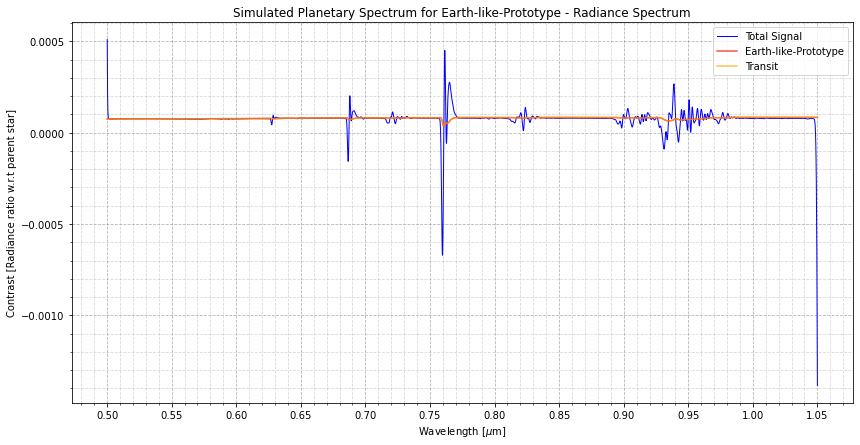

In [38]:
print(df_rad)

plt.figure(figsize=(14, 7))
plt.plot(df_rad['Wave/freq'], df_rad['Total'], label='Total Signal', color='blue', linewidth=1)
plt.plot(df_rad['Wave/freq'], df_rad['Earth-like-Prototype'],
         label='Earth-like-Prototype', 
         color='red',
         linewidth=1.5,
         alpha=0.7)
plt.plot(df_rad['Wave/freq'], df_rad['Transit'],
         label='Transit', 
         color='orange', 
         alpha=0.7)

plt.xlabel('Wavelength [$\mu$m]')
#plt.xscale('log')
plt.ylabel('Contrast [Radiance ratio w.r.t parent star]') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototype - Radiance Spectrum')
plt.legend()

ax = plt.gca() 

ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_major_locator(MultipleLocator(0.0005))

ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(0.0001))


plt.grid(visible=True, 
         which='major', 
         color='grey', 
         linestyle='--', 
         alpha=0.6)
plt.grid(visible=True, 
         which='minor', 
         color='grey', 
         linestyle='--', 
         alpha=0.3) 

plt.legend()
plt.show()

      Wave/freq  Telluric
0      0.500100  0.886995
1      0.500200  0.886985
2      0.500300  0.886974
3      0.500400  0.886961
4      0.500500  0.886947
...         ...       ...
3705   1.049148  0.990623
3706   1.049358  0.990506
3707   1.049568  0.990402
3708   1.049778  0.990314
3709   1.049988  0.990244

[3710 rows x 2 columns]


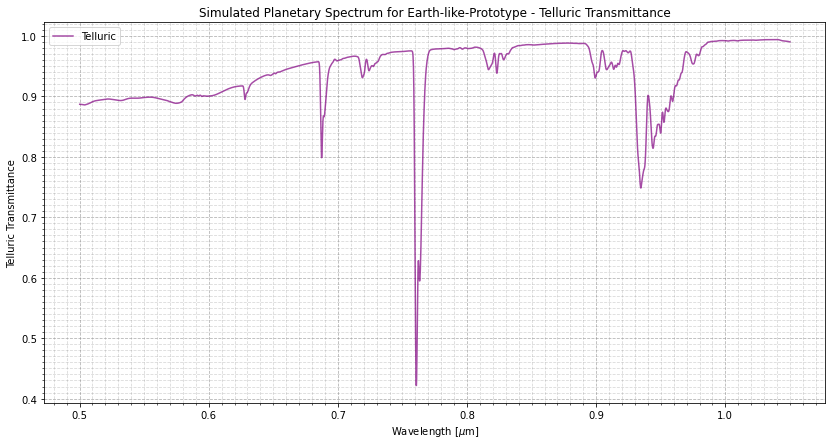

In [39]:
print(df_tel)

plt.figure(figsize=(14, 7))
plt.plot(df_tel['Wave/freq'], df_tel['Telluric'],
         label='Telluric', 
         color='purple', 
         alpha=0.7)


plt.xlabel('Wavelength [$\mu$m]')
#plt.xscale('log')
plt.ylabel('Telluric Transmittance') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototype - Telluric Transmittance')
plt.legend()

ax = plt.gca() 

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))


plt.grid(visible=True, 
         which='major', 
         color='grey', 
         linestyle='--', 
         alpha=0.6)
plt.grid(visible=True, 
         which='minor', 
         color='grey', 
         linestyle='--', 
         alpha=0.3)

plt.legend()
plt.show()

      Wave/freq  Transmittance
0      0.500100   6.554488e-07
1      0.500200   6.558229e-07
2      0.500300   6.562469e-07
3      0.500400   6.567147e-07
4      0.500500   6.572190e-07
...         ...            ...
3705   1.049148   4.104328e-07
3706   1.049358   4.105852e-07
3707   1.049568   4.107281e-07
3708   1.049778   4.108548e-07
3709   1.049988   4.109608e-07

[3710 rows x 2 columns]


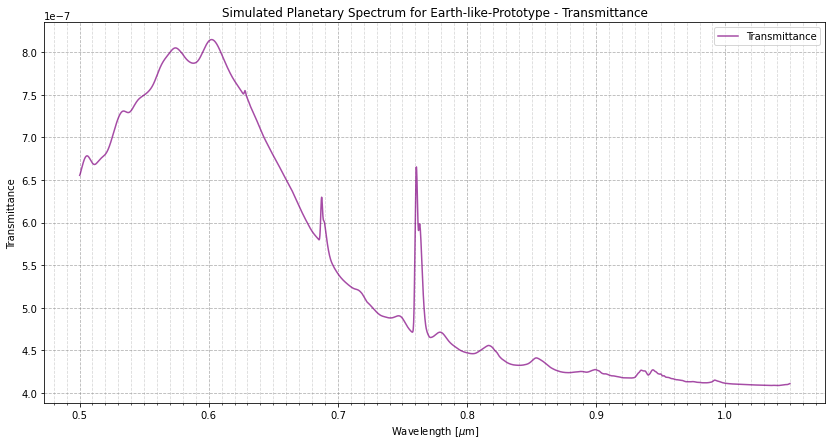

In [40]:
print(df_trn)

plt.figure(figsize=(14, 7))
plt.plot(df_trn['Wave/freq'], df_trn['Transmittance'],
         label='Transmittance', 
         color='purple', 
         alpha=0.7)


plt.xlabel('Wavelength [$\mu$m]')
#plt.xscale('log')
plt.ylabel('Transmittance') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototype - Transmittance')
plt.legend()

ax = plt.gca() 

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.5e-7))

ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(1e-7))


plt.grid(visible=True, 
         which='major', 
         color='grey', 
         linestyle='--', 
         alpha=0.6)
plt.grid(visible=True, 
         which='minor', 
         color='grey', 
         linestyle='--', 
         alpha=0.3)

plt.legend()
plt.show()

# Comparing atmospheres

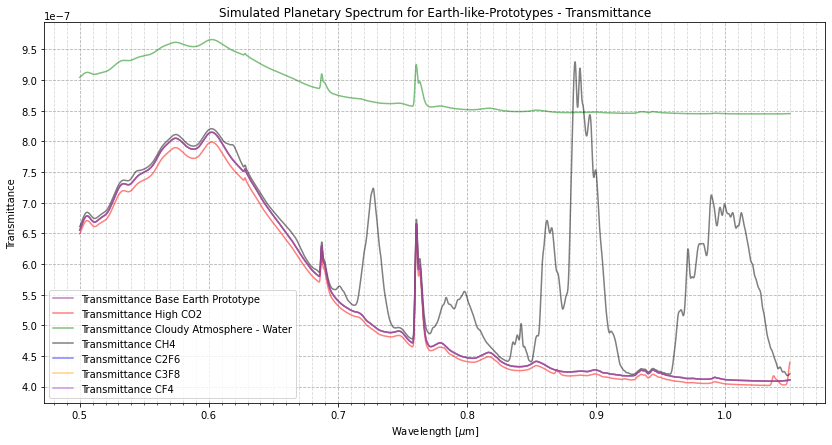

Is C2F6 data identical to Base Earth? False
      Wave/freq         Total
0      0.500000  6.551287e-07
1      0.500100  6.554488e-07
2      0.500200  6.558229e-07
3      0.500300  6.562469e-07
4      0.500400  6.567147e-07
...         ...           ...
3706   1.049148  4.104328e-07
3707   1.049358  4.105852e-07
3708   1.049568  4.107281e-07
3709   1.049778  4.108548e-07
3710   1.049988  4.109608e-07

[3711 rows x 2 columns]
      Wave/freq  Transmittance
0      0.500100   6.554488e-07
1      0.500200   6.558229e-07
2      0.500300   6.562469e-07
3      0.500400   6.567147e-07
4      0.500500   6.572190e-07
...         ...            ...
3705   1.049148   4.104328e-07
3706   1.049358   4.105852e-07
3707   1.049568   4.107281e-07
3708   1.049778   4.108548e-07
3709   1.049988   4.109608e-07

[3710 rows x 2 columns]


In [41]:
df_co2 = pd.read_csv('psg_trn-40000ppm-CO2.txt', delim_whitespace=True).dropna() # toxicity maximum for human life
df_CH4 = pd.read_csv('psg_trn-10000ppmCH4.txt', delim_whitespace=True).dropna()
df_cloudy =pd.read_csv('psg_trn-Cloudy-water.txt', delim_whitespace=True).dropna()
df_C2F6 =pd.read_csv('psg_trn-c2f6.txt', delim_whitespace=True).dropna()
df_C3F8 =pd.read_csv('psg_trn-C3F8.txt', delim_whitespace=True).dropna()
df_CF4 =pd.read_csv('psg_trn-CF4.txt', delim_whitespace=True).dropna()



plt.figure(figsize=(14, 7))

# -----------LIFE CATEGORY----------------

plt.plot(df_trn['Wave/freq'], df_trn['Transmittance'],
         label='Transmittance Base Earth Prototype', 
         color='purple', 
         alpha=0.5)


plt.plot(df_co2['Wave/freq'], df_co2['Total'],
         label='Transmittance High CO2', 
         color='red', 
         alpha=0.5)

plt.plot(df_cloudy['Wave/freq'], df_cloudy['Total'],
         label='Transmittance Cloudy Atmosphere - Water', 
         color='green', 
         alpha=0.5)

plt.plot(df_CH4['Wave/freq'], df_CH4['Total'],
         label='Transmittance CH4', 
         color='Black', 
         alpha=0.5)

#--------------IMPORTANT------------------------------
# Technosignatures (Schweiterman et. al., 2024)
# C2F6, C3F8, SF6, NF3, and CF4 as greenhouse gases.
# These were run for TRAPPIST system and TRAPPIST 1f
# They used 100pm so we will replicate this in this study

#---------------------------------------------------------

# TECHNOSIGNATURE SECTION ------------------------------

plt.plot(df_C2F6['Wave/freq'], df_C2F6['Total'],
         label='Transmittance C2F6', 
         color='blue', 
         alpha=0.5)
# This overlaps with the Earth base profile 

plt.plot(df_C3F8['Wave/freq'], df_C3F8['Total'],
         label='Transmittance C3F8', 
         color='orange', 
         alpha=0.5)
# Overlaps with Earth base profile

plt.plot(df_CF4['Wave/freq'], df_CF4['Total'],
         label='Transmittance CF4', 
         color='darkorchid', 
         alpha=0.5)

plt.xlabel('Wavelength [$\mu$m]')
#plt.yscale('log')

plt.ylabel('Transmittance') 
plt.title('Simulated Planetary Spectrum for Earth-like-Prototypes - Transmittance')
plt.legend()

ax = plt.gca() 

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.5e-7))

ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(1e-7))



plt.grid(visible=True, 
         which='major', 
         color='grey', 
         linestyle='--', 
         alpha=0.6)
plt.grid(visible=True, 
         which='minor', 
         color='grey', 
         linestyle='--', 
         alpha=0.3)

plt.legend()
plt.show()

# Check if the values are exactly equal
are_identical = df_C2F6['Total'].equals(df_trn['Transmittance'])
print(f"Is C2F6 data identical to Base Earth? {are_identical}")
print(df_C2F6)
print(df_trn)

## In order to project what the PLATO satellite will detect with its cameras we must perform a mathematical convolution to blur and smoothen the data because the output of the PLATO is less resolution than the PSG output. We must also perform a bandpass integration to calculate how much light will pass through the PLATO cameras.

### Bandpass integration - calulates the total throughput (transmission efficiency) is how much light will pass though the telescope to be recorded by the camera sensor. It is expected that the throughput will not be at 100% because of the influence of elements like mirrors, the colour filter and the sensor (which may not measure all the photons that hit it).


### Instrument convolution - Assuming the 'smearing' of data by the instrument which is doing recording. The satellite will not record high resolution data. Therefore we incorporate a convolution which is the application of a function to blur the data such as a gaussian function which makes the sharp peaks more realisitic or depicts them in terms of the blurred attributes of the real machinery.

Steps will be as follows:
1. Convolution of the PSG data into a PLATO like version
2. Compute the throughput of the data i.e. how much light will pass through PLATO

In [42]:
def simulate_plato_output(psg_wave, psg_trans, plato_wave, plato_throughput, resolution_sigma=2.0):
    """
    Transforms high-resolution planet spectrum data into an integrated satellite signal.
    
    Parameters:
    -----------
    psg_wave : numpy.ndarray
        Wavelength array of the planetary atmosphere model (converted to Nanometers).
    psg_trans : numpy.ndarray
        Transmittance/Radiance column from PSG (pre-cleaned of negative values).
    plato_wave : numpy.ndarray
        Wavelength grid of the PLATO camera bandpass specification from Table 1.
    plato_throughput : numpy.ndarray
        Camera efficiency fraction vector (E_cam) for either BOL or EOL states.
    resolution_sigma : float, optional
        Standard deviation in data row units used to control the Gaussian blur. Default is 2.0.
        
    Returns:
    --------
    float
        The total throughput-weighted integrated signal observed by the satellite.
    """
    
    # --- INSTRUMENTAL RESOLUTION CONVOLUTION (SMEARING) ---
    # Softens sharp lines to replicate physical optical blur across rows
    convolved_trans = gaussian_filter1d(psg_trans, sigma=resolution_sigma)
    
    # --- GRID MATCHING INTERPOLATION ---
    # Maps the 13-point PLATO efficiency curve smoothly onto the dense planet data grid
    interp_plato = interp1d(plato_wave, plato_throughput, bounds_error=False, fill_value=0.0)
    T_plato = interp_plato(psg_wave)
    
    # --- BANDPASS INTEGRATION & NORMALIZATION ---
    # Computes the raw signal area and divides it by the total window transmission area
    numerator = simpson(convolved_trans * T_plato, psg_wave)
    denominator = simpson(T_plato, psg_wave)
    
    # Mathematical protection loop to prevent a system crash if grids fail to overlap
    if denominator == 0:
        return np.nan
        
    # Return the clean, normalized, dimensionless integrated decimal fraction
    return numerator / denominator


Atmosphere Model          | BOL Signal (ppm)   | EOL Signal (ppm)   | Signal Loss (ppm) 
-------------------------------------------------------------------------------------
Base Earth Prototype      | 0.598              | 0.597              | 0.002             
High CO2 Atmosphere       | 0.588              | 0.587              | 0.002             
Cloudy Atmosphere H2O     | 0.895              | 0.895              | 0.000             
High CH4 Atmosphere       | 0.639              | 0.638              | 0.001             
100ppm Atmosphere C2F6    | 0.598              | 0.597              | 0.002             
100ppm Atmosphere C3F8    | 0.598              | 0.597              | 0.002             
100ppm Atmosphere CF4     | 0.598              | 0.596              | 0.002             


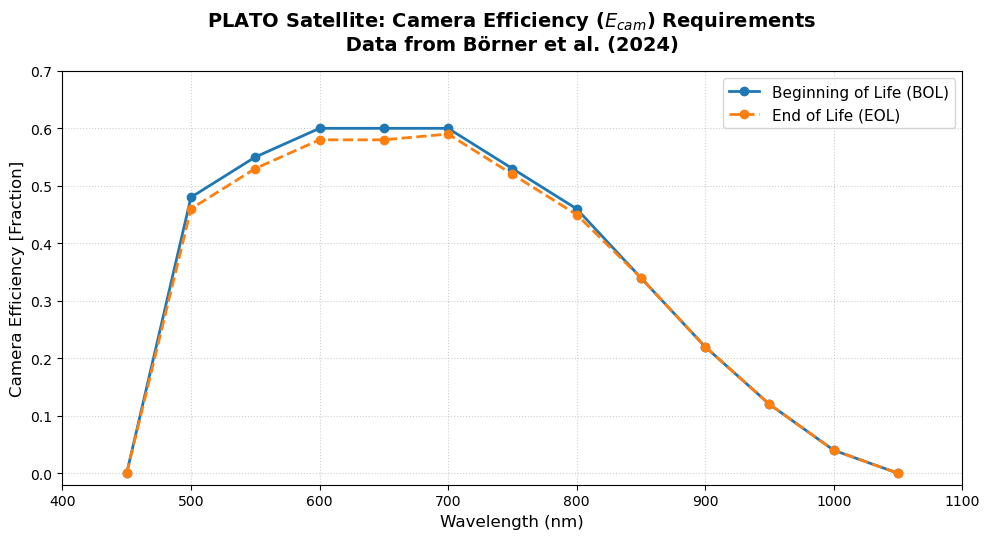

In [45]:
# Data taken from Börner et al.(2024, 6)

# ---  BOTH BOL AND EOL SPECIFICATIONS FROM TABLE 1 Börner et al.(2024) ---
PLATO_WAVE_NM = np.array([450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1050])

# Camera Efficiency (E_cam) for both mission states
plato_throughput_bol = np.array([0.00, 0.48, 0.55, 0.60, 0.60, 0.60, 0.53, 0.46, 0.34, 0.22, 0.12, 0.04, 0.00])
plato_throughput_eol = np.array([0.00, 0.46, 0.53, 0.58, 0.58, 0.59, 0.52, 0.45, 0.34, 0.22, 0.12, 0.04, 0.00])

#NOTE. eol is specified to be in about 4.5 years 


# --- RUNNING CALCULATIONS FOR BEGINNING OF LIFE (BOL) ---
bol_base_earth = simulate_plato_output(
    psg_wave=df_trn['Wave/freq'].values * 1000, 
    psg_trans=df_trn['Transmittance'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_bol,
    resolution_sigma=2.0
)

bol_high_co2 = simulate_plato_output(
    psg_wave=df_co2['Wave/freq'].values * 1000, 
    psg_trans=df_co2['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_bol,
    resolution_sigma=2.0
)

bol_cloudy = simulate_plato_output(
    psg_wave=df_cloudy['Wave/freq'].values * 1000, 
    psg_trans=df_cloudy['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_bol,
    resolution_sigma=2.0
)

bol_10000ppm_CH4 = simulate_plato_output(
    psg_wave=df_CH4['Wave/freq'].values * 1000, 
    psg_trans=df_CH4['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_bol,
    resolution_sigma=2.0
)


bol_100ppm_C2F6 = simulate_plato_output(
    psg_wave=df_C2F6['Wave/freq'].values * 1000, 
    psg_trans=df_C2F6['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_bol,
    resolution_sigma=2.0
)

bol_100ppm_C3F8 = simulate_plato_output(
    psg_wave=df_C3F8['Wave/freq'].values * 1000, 
    psg_trans=df_C3F8['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_bol,
    resolution_sigma=2.0
)

bol_100ppm_CF4 = simulate_plato_output(
    psg_wave=df_CF4['Wave/freq'].values * 1000, 
    psg_trans=df_CF4['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_bol,
    resolution_sigma=2.0
)

# --- RUNNING CALCULATIONS FOR END OF LIFE (EOL) ---
eol_base_earth = simulate_plato_output(
    psg_wave=df_trn['Wave/freq'].values * 1000, 
    psg_trans=df_trn['Transmittance'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_eol,
    resolution_sigma=2.0
)

eol_high_co2 = simulate_plato_output(
    psg_wave=df_co2['Wave/freq'].values * 1000, 
    psg_trans=df_co2['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_eol,
    resolution_sigma=2.0
)

eol_cloudy = simulate_plato_output(
    psg_wave=df_cloudy['Wave/freq'].values * 1000, 
    psg_trans=df_cloudy['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_eol,
    resolution_sigma=2.0
)

eol_10000ppm_CH4 = simulate_plato_output(
    psg_wave=df_CH4['Wave/freq'].values * 1000, 
    psg_trans=df_CH4['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_eol,
    resolution_sigma=2.0
)

eol_100ppm_C2F6 = simulate_plato_output(
    psg_wave=df_C2F6['Wave/freq'].values * 1000, 
    psg_trans=df_C2F6['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_eol,
    resolution_sigma=2.0
)

eol_100ppm_C3F8 = simulate_plato_output(
    psg_wave=df_C3F8['Wave/freq'].values * 1000, 
    psg_trans=df_C3F8['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_eol,
    resolution_sigma=2.0
)

eol_100ppm_CF4 = simulate_plato_output(
    psg_wave=df_CF4['Wave/freq'].values * 1000, 
    psg_trans=df_CF4['Total'].clip(lower=0.0).values, 
    plato_wave=PLATO_WAVE_NM, 
    plato_throughput=plato_throughput_eol,
    resolution_sigma=2.0
)

# ---  EXPERIMENT COMPARISON DATA TABLE ---
print(f"{'Atmosphere Model':<25} | {'BOL Signal (ppm)':<18} | {'EOL Signal (ppm)':<18} | {'Signal Loss (ppm)':<18}")
print("-" * 85)
print(f"{'Base Earth Prototype':<25} | {bol_base_earth * 1e6:<18.3f} | {eol_base_earth * 1e6:<18.3f} | {(bol_base_earth - eol_base_earth) * 1e6:<18.3f}")
print(f"{'High CO2 Atmosphere':<25} | {bol_high_co2 * 1e6:<18.3f} | {eol_high_co2 * 1e6:<18.3f} | {(bol_high_co2 - eol_high_co2) * 1e6:<18.3f}")
print(f"{'Cloudy Atmosphere H2O':<25} | {bol_cloudy * 1e6:<18.3f} | {eol_cloudy * 1e6:<18.3f} | {(bol_cloudy - eol_cloudy) * 1e6:<18.3f}")
print(f"{'High CH4 Atmosphere':<25} | {bol_10000ppm_CH4 * 1e6:<18.3f} | {eol_10000ppm_CH4 * 1e6:<18.3f} | {(bol_10000ppm_CH4 - eol_10000ppm_CH4) * 1e6:<18.3f}")
print(f"{'100ppm Atmosphere C2F6':<25} | {bol_100ppm_C2F6 * 1e6:<18.3f} | {eol_100ppm_C2F6 * 1e6:<18.3f} | {(bol_100ppm_C2F6 - eol_100ppm_C2F6) * 1e6:<18.3f}")
print(f"{'100ppm Atmosphere C3F8':<25} | {bol_100ppm_C3F8 * 1e6:<18.3f} | {eol_100ppm_C3F8 * 1e6:<18.3f} | {(bol_100ppm_C3F8 - eol_100ppm_C3F8) * 1e6:<18.3f}")
print(f"{'100ppm Atmosphere CF4':<25} | {bol_100ppm_CF4 * 1e6:<18.3f} | {eol_100ppm_CF4 * 1e6:<18.3f} | {(bol_100ppm_CF4 - eol_100ppm_CF4) * 1e6:<18.3f}")
#------------------------------------------------------------------
#Important Information
#--------------------------------------------------------------------
# Here ppm is used to measure photons of light as measured from the PLATO satellite

#Please note that <25 and <18 are just text alignment specifications
# .clip function is used to make sure the lower boundary remains at 0.0


#----------------------------------------------------------------------
plt.figure(figsize=(10, 5.5), dpi=100)

#  Beginning of Life curve (with blue circles)
plt.plot(PLATO_WAVE_NM, plato_throughput_bol, 
         label='Beginning of Life (BOL)', 
         color='#1f77b4', marker='o', linewidth=2, markersize=6)

#  End of Life curve (with orange/red circles)
plt.plot(PLATO_WAVE_NM, plato_throughput_eol, 
         label='End of Life (EOL)', 
         color='#ff7f0e', marker='o', linestyle='--', linewidth=2, markersize=6)

plt.title('PLATO Satellite: Camera Efficiency ($E_{cam}$) Requirements \n Data from Börner et al. (2024) ',
          fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Camera Efficiency [Fraction]', fontsize=12)

#  physical boundaries
plt.xlim(400, 1100)
plt.ylim(-0.02, 0.70)

#  structured gridlines and a legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11, frameon=True)


plt.tight_layout()
plt.show()

### Data loss calculation

In [46]:
#  statistical variance of a pure, sharp planet data
pure_variance = np.var(df_cloudy['Total'])

from scipy.ndimage import gaussian_filter1d
blurred_data = gaussian_filter1d(df_cloudy['Total'].values, sigma=2.0)
blurred_variance = np.var(blurred_data)

# The percentage of sharpness lost
percentage_loss_smear = ((pure_variance - blurred_variance) / pure_variance) * 100

print(f"Spectral sharpness lost to optical smearing: {percentage_loss_smear:.2f}%")


Spectral sharpness lost to optical smearing: 0.03%


#  Results and Discussion
PLATO instrument delivers an optimal random and photon noise envelope of 31.3 ppm at Beginning of Life (BOL), which degrades to 45.6 ppm at End of Life (EOL) due to space radiation and lens aging (Börner, 2024). A photon noise envelope is the random fluctuation in the number of particles (i.e. photons) hitting the camera sensors.
For a cloudy planet for example the value of 0.9ppm means the PLATO noise limit is above this and that this signal would not be detected. PLATO therefore cannot detect the water cloud feature on its own.
Here ppm is used to measure photons of light as measured from the PLATO satellite. Therefore, PLATO captures less than or approximately one photon for every million of photons from the star.  


# Limitations

1. While atmospheric concentrations
were varied for this project by changing specific
parameters such as CO2, it is good to acknowledge that these changes in value do not happen in
isolation as there are complex chemical processes
which occur between molecules in the atmosphere
and also with the surface of the planet through terrestrial interractions, at least on rocky planetary
bodies.  
2. For a cloudy planet there is no planet that
has an albedo of 1.0 which would effectively be a
body that reflects all incoming light so the consistency of the albedo of a well known planet is used
which was Venus. The albedo of 0.75 was used for
a cloudy Earth-like planet.  

# Conclusions

The atmospheric technosignatures explored in this study will be invisible to PLATO.
What is noticable is if there is high Cloudy H20 and very high CO2 this is distinguishable using PSG but on the PLATO level they are not going to be distinguishable for an Earthlike plant around a solar type star. The reason for the artificial greenhouse gases to have no diference from the base transmittance line of the exoplanet is that the flourinated compounds are transparent in the visible spectrum between 0.45-1.05 micrometers.


# Bibliography 

Börner, A., Cabrera, J., Rauer, H., Grießbach, D., Paproth, C., Samadi, R., Appourchaux, T., & PLATO Performance Team. (2024). PLATO’s signal and noise budget. Experimental Astronomy, 58(1), 1–26. doi.org

Cabrera, J., Rauer, H., Börner, A., Grießbach, D., Paproth, C., Samadi, R., & PLATO Performance Team. (2026). Assessment of PLATO science performance. arXiv preprint arXiv:2604.04818. https://arxiv.org/abs/2604.04818

Krissansen-Totton J, Olson S, Catling DC. (2018) Disequilibrium biosignatures over Earth history and implications for detecting exoplanet life. Sci Adv. 2018 Jan 24;4(1):eaao5747. doi: 10.1126/sciadv.aao5747. PMID: 29387792; PMCID: PMC5787383.

Rauer, H., Aerts, C., Cabrera, J., & PLATO Consortium. (2025). The PLATO mission. Experimental Astronomy, 59(3), 45–68. doi.org

Schwieterman,  Edward W. et al. (2024) Artificial Greenhouse Gases as Exoplanet Technosignatures ApJ 969 20 https://iopscience.iop.org/article/10.3847/1538-4357/ad4ce8

Villanueva, Geronimo.L, Michael D. Smith, Silvia Protopapa, Sara Faggi, Avi M. MandellJournal of Quantitative Spectroscopy and Radiative Transfer, ISSN: 0022-4073, Vol: 217, Page: 86-104, 2018. https://doi.org/10.1016/j.jqsrt.2018.05.023
